# Dilution of Meaning: Multi-Text Experiment

This notebook scales the iterative rewriting experiment to process all text files in the `texts/` directory. It also introduces semantic tracking using embeddings and PCA (Principal Component Analysis) to visualize how the meaning of each text "drifts" across iterations.

## Environment Setup

First, we install and import the necessary libraries. This includes `transformers` for the LLM, `sentence-transformers` for embeddings, and `scikit-learn` for PCA.

In [1]:
%pip install -q sentence-transformers scikit-learn matplotlib tqdm mlx-lm


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import glob
import torch
import matplotlib.pyplot as plt
import numpy as np
from transformers import pipeline
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from tqdm.notebook import tqdm
import time
import nltk
from nltk.tokenize import sent_tokenize
from mlx_lm import load, generate, batch_generate
from matplotlib.collections import LineCollection

# nltk.download('punkt_tab')

# Set device
device = "cpu"
if torch.backends.mps.is_available():
    device = torch.device("mps")

if torch.cuda.is_available():
    device = toch.device("cuda")

print(device)

mps


## Model Initialization

We initialize two models:
1.  **Generation Model**: The larger LLM used for rewriting (`google/gemma-3n-E2B-it`).
2.  **Embedding Model**: A specialized model for generating semantic vectors (`all-MiniLM-L6-v2`).

In [88]:
# Large Language Model for Generation
#gen_model_id = "Qwen/Qwen3-0.7B"
# gen_model_id = "Qwen/Qwen3.5-0.8B" 
# sum_model_id = "Qwen/Qwen3.5-0.8B"
gen_model_id = "mlx-community/Qwen3-0.6B-4bit-DWQ-053125" 
sum_model_id = "mlx-community/Qwen3-0.6B-4bit-DWQ-053125" 

print(f"Loading Generation Model: {gen_model_id}...")
# gen = pipeline("text-generation", model=gen_model_id, device=device)
gen, gen_tokenizer = load(gen_model_id)
#print(f"Loading Summarization Model: {gen_model_id}...")
#summarize = pipeline("text-generation", model=sum_model_id, device=device)
summarize, sum_tokenizer = load(sum_model_id)
# Sentence Transformer for Embeddings
print("Loading Embedding Model...")
embed_model = SentenceTransformer('all-mpnet-base-v2', device=device)


Loading Generation Model: mlx-community/Qwen3-0.6B-4bit-DWQ-053125...


Fetching 10 files:   0%|          | 0/10 [00:00<?, ?it/s]

Fetching 10 files:   0%|          | 0/10 [00:00<?, ?it/s]

Loading Embedding Model...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
import os
from tqdm import tqdm

iterations = 50
batch_size = 1

# Define the directory where you want to save the files
output_dir = "./iteration_outputs"
trimmed_dir = "./trimmed_outputs"

# Create the directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)
os.makedirs(trimmed_dir, exist_ok=True)

# Optional: Keep a main log file for the experiment overview
with open(os.path.join(output_dir, "_experiment_log.txt"), "w", encoding='utf-8') as f:
    f.write("Dilution of Meaning//Semantic drift experiment type 2\n")

text = "For sale: Baby boots, never worn."
results = []

for i in tqdm(range(1, iterations + 1), desc="Processing Iterations"):
    # Define the specific file paths for this iteration
    iteration_file = os.path.join(output_dir, f"iteration_{i:03d}.txt")
    trimmed_file = os.path.join(trimmed_dir, f"iteration_{i:03d}_trimmed.txt")
    
    # --- GENERATION STEP ---
    generate_prompts = gen_tokenizer.apply_chat_template(
        [
            {'role': 'system', 'content': 'Write a scene of story of around 500 words based on the following prompt: '},
            {"role": "user", "content": text}
        ],
        add_generation_prompt=True,
        enable_thinking=False
    )
    regenerated_output = generate(gen, gen_tokenizer, prompt=generate_prompts, max_tokens=10000)
    results.append(regenerated_output)
    
    # --- SUMMARIZATION STEP ---
    summarize_prompt = sum_tokenizer.apply_chat_template(
        [
            {'role': 'system', 'content': 'Write a one sentence summary that would go with this scene, capturing the main plot, theme, genre, and other relevant information.'},
            {'role': 'user', 'content': regenerated_output}
        ],
        add_generation_prompt=True,
        enable_thinking=False
    )
    summarized = generate(summarize, sum_tokenizer, prompt=summarize_prompt, max_tokens=512)
    
    # --- EMBEDDING STEP ---
    new_embeddings = embed_model.encode([regenerated_output], batch_size=batch_size)
    
    # --- RECORD KEEPING ---
    # 1. Write the detailed file with prompts, outputs, and summaries
    with open(iteration_file, "w", encoding='utf-8') as f:
        f.write(f"=== ITERATION {i} ===\n\n")
        f.write(f"--- Input Prompt ---\n{text}\n\n")
        f.write(f"--- Generated Text ---\n{regenerated_output}\n\n")
        f.write(f"--- Summary (Next Prompt) ---\n{summarized}\n")
        
    # 2. Write the trimmed file containing ONLY the generated text
    with open(trimmed_file, "w", encoding='utf-8') as f:
        f.write(regenerated_output)
    
    # Update the text variable for the next iteration loop
    text = summarized

Processing Iterations: 100%|██████████| 100/100 [01:38<00:00,  1.01it/s]


Loading model: all-MiniLM-L6-v2...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded.
Generating file vectors...

Cosine Distance Matrix (Shape: (100, 100))
Rows/Cols correspond to the files in the order they were processed.

Files: ['iteration_001_trimmed.txt', 'iteration_002_trimmed.txt', 'iteration_003_trimmed.txt', 'iteration_004_trimmed.txt', 'iteration_005_trimmed.txt', 'iteration_006_trimmed.txt', 'iteration_007_trimmed.txt', 'iteration_008_trimmed.txt', 'iteration_009_trimmed.txt', 'iteration_010_trimmed.txt', 'iteration_011_trimmed.txt', 'iteration_012_trimmed.txt', 'iteration_013_trimmed.txt', 'iteration_014_trimmed.txt', 'iteration_015_trimmed.txt', 'iteration_016_trimmed.txt', 'iteration_017_trimmed.txt', 'iteration_018_trimmed.txt', 'iteration_019_trimmed.txt', 'iteration_020_trimmed.txt', 'iteration_021_trimmed.txt', 'iteration_022_trimmed.txt', 'iteration_023_trimmed.txt', 'iteration_024_trimmed.txt', 'iteration_025_trimmed.txt', 'iteration_026_trimmed.txt', 'iteration_027_trimmed.txt', 'iteration_028_trimmed.txt', 'iteration_029_trimmed.txt

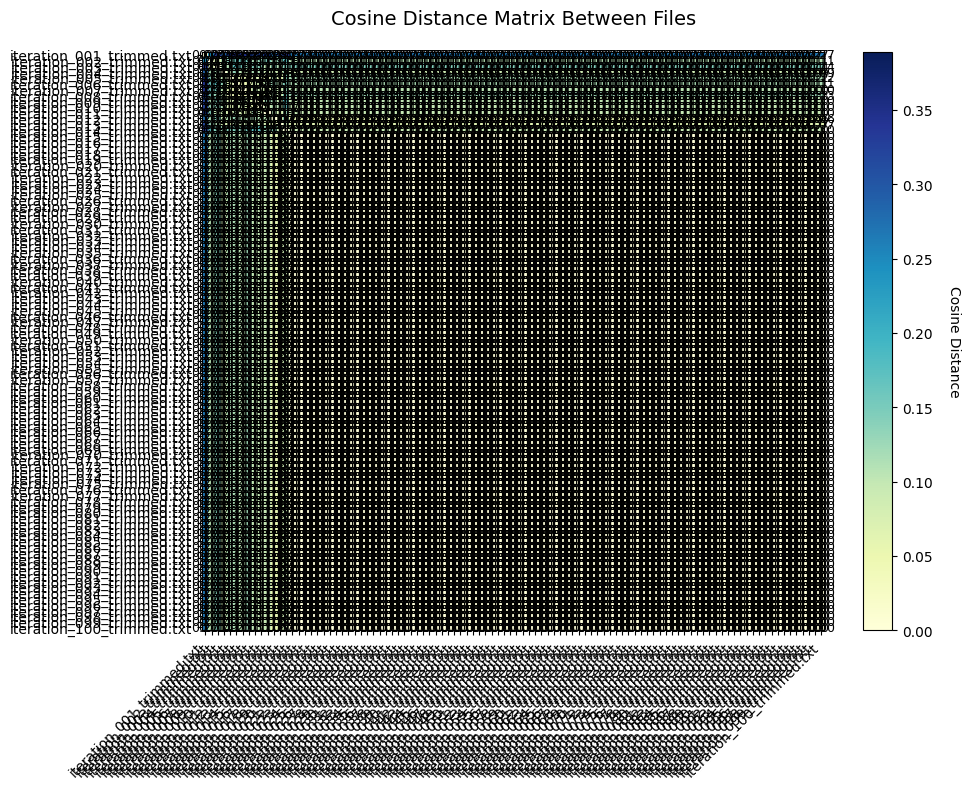

Semantic drift velocity graph saved as 'semantic_drift_velocity.png'


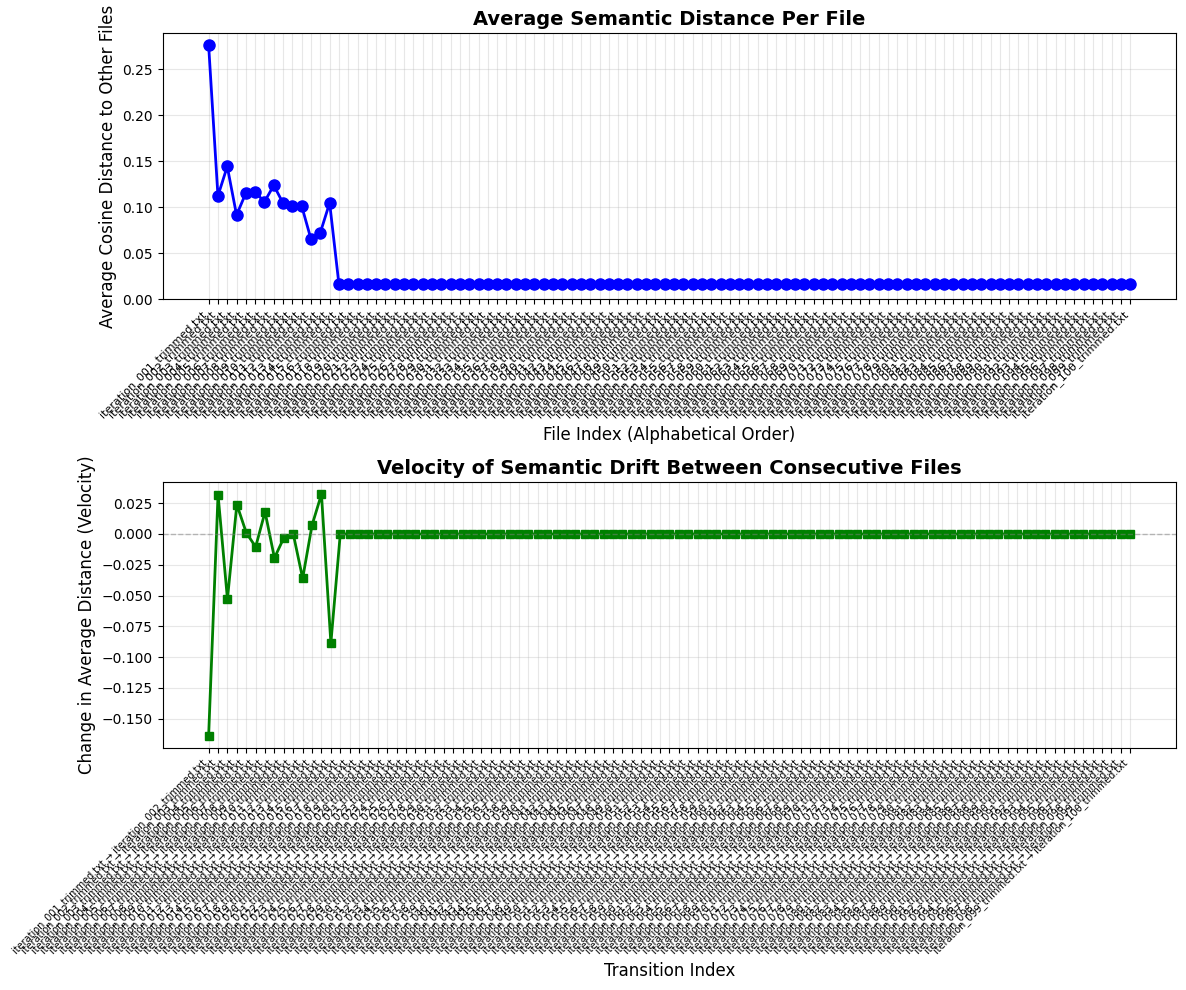


=== Semantic Drift Summary ===
Mean Average Distance: 0.0301
Std Dev of Average Distance: 0.0393
Max Average Distance: 0.2763 (iteration_001_trimmed.txt)
Min Average Distance: 0.0160 (iteration_015_trimmed.txt)
Mean Drift Velocity: -0.0026
Max Positive Drift: 0.0323
Max Negative Drift: -0.1639


In [90]:
from scipy.spatial.distance import cdist

# Ensure NLTK data is available
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

def get_file_vector(file_path, model):
    """
    Reads a text file, splits it into sentences, embeds them,
    and returns the mean vector of all sentence embeddings.
    """
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            text = f.read()
        
        if not text.strip():
            return None

        # Split text into sentences
        sentences = sent_tokenize(text)
        
        if not sentences:
            return None

        # Generate embeddings for all sentences
        sentence_embeddings = model.encode(sentences, convert_to_numpy=True, show_progress_bar=False)
        
        # Aggregate: Mean pooling to create one vector per file
        file_vector = np.mean(sentence_embeddings, axis=0)
        return file_vector

    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

def calculate_file_distances(directory_path, model_name='all-MiniLM-L6-v2'):
    # 1. Load the embedding model
    print(f"Loading model: {model_name}...")
    model = SentenceTransformer(model_name)
    print("Model loaded.")

    # 2. Find all text files in the directory (sorted alphabetically)
    file_paths = sorted(glob.glob(os.path.join(directory_path, '*.txt')))
    
    if not file_paths:
        print("No .txt files found in the directory.")
        return

    # 3. Generate a vector for each file
    print("Generating file vectors...")
    file_vectors = []
    valid_file_names = []

    for path in file_paths:
        vector = get_file_vector(path, model)
        if vector is not None:
            file_vectors.append(vector)
            valid_file_names.append(os.path.basename(path))

    if len(file_vectors) < 2:
        print("Need at least 2 valid files to calculate distances.")
        return

    # Convert to numpy array
    all_vectors = np.array(file_vectors)

    # 4. Calculate pairwise Cosine Distance
    distance_matrix = cdist(all_vectors, all_vectors, metric='cosine')

    # 5. Display results
    print(f"\nCosine Distance Matrix (Shape: {distance_matrix.shape})")
    print("Rows/Cols correspond to the files in the order they were processed.\n")
    
    print("Files:", valid_file_names)
    print("\nDistance Matrix:")
    print(np.round(distance_matrix, 4))

    # Optional: Find the most similar pair (lowest distance)
    min_dist_idx = np.unravel_index(np.argmin(distance_matrix), distance_matrix.shape)
    if distance_matrix[min_dist_idx] == 0 and min_dist_idx[0] == min_dist_idx[1]:
        mask = ~np.eye(distance_matrix.shape[0], dtype=bool)
        min_dist_idx = np.unravel_index(np.argmin(distance_matrix[mask]), distance_matrix.shape)
    
    file_a = valid_file_names[min_dist_idx[0]]
    file_b = valid_file_names[min_dist_idx[1]]
    print(f"\nMost similar files: '{file_a}' and '{file_b}' (Distance: {distance_matrix[min_dist_idx]:.4f})")

    # 6. Visualize the distance matrix using matplotlib
    visualize_distance_matrix(distance_matrix, valid_file_names)

    # 7. Visualize semantic drift/change across files
    visualize_semantic_drift(distance_matrix, valid_file_names)

def visualize_distance_matrix(distance_matrix, file_names):
    """
    Visualize the cosine distance matrix as a heatmap.
    """
    plt.figure(figsize=(10, 8))
    
    im = plt.imshow(distance_matrix, cmap='YlGnBu', aspect='auto')
    
    plt.xticks(range(len(file_names)), file_names, rotation=45, ha='right')
    plt.yticks(range(len(file_names)), file_names)
    
    cbar = plt.colorbar(im)
    cbar.set_label('Cosine Distance', rotation=270, labelpad=20)
    
    plt.title('Cosine Distance Matrix Between Files', fontsize=14, pad=20)
    
    for i in range(len(file_names)):
        for j in range(len(file_names)):
            plt.text(j, i, f'{distance_matrix[i, j]:.2f}', 
                    ha='center', va='center', color='black', fontsize=9)
    
    plt.tight_layout()
    plt.savefig('cosine_distance_heatmap.png', dpi=300, bbox_inches='tight')
    print("\nHeatmap saved as 'cosine_distance_heatmap.png'")
    plt.show()

def visualize_semantic_drift(distance_matrix, file_names):
    """
    Visualize the 'velocity of semantic drift' - how average distance changes
    between consecutive files in the sorted list.
    """
    n = len(file_names)
    if n < 2:
        print("Need at least 2 files to visualize semantic drift.")
        return

    # Calculate average distance from each file to its neighbors
    avg_distances = []
    for i in range(n):
        # Get distances to all other files
        distances = distance_matrix[i, :]
        # Exclude self-comparison (diagonal)
        other_distances = distances[~np.eye(n, dtype=bool)[i, :]]
        avg_distances.append(np.mean(other_distances))

    # Calculate change in average distance between consecutive files
    drift_changes = []
    for i in range(len(avg_distances) - 1):
        change = avg_distances[i + 1] - avg_distances[i]
        drift_changes.append(change)

    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

    # Plot 1: Average Distance per File
    ax1.plot(range(n), avg_distances, marker='o', linewidth=2, markersize=8, color='blue')
    ax1.set_xlabel('File Index (Alphabetical Order)', fontsize=12)
    ax1.set_ylabel('Average Cosine Distance to Other Files', fontsize=12)
    ax1.set_title('Average Semantic Distance Per File', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.set_xticks(range(n))
    ax1.set_xticklabels(file_names, rotation=45, ha='right', fontsize=8)
    ax1.set_ylim(bottom=0)

    # Plot 2: Velocity of Semantic Drift
    ax2.plot(range(len(drift_changes)), drift_changes, marker='s', linewidth=2, markersize=6, color='green')
    ax2.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    ax2.set_xlabel('Transition Index', fontsize=12)
    ax2.set_ylabel('Change in Average Distance (Velocity)', fontsize=12)
    ax2.set_title('Velocity of Semantic Drift Between Consecutive Files', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.set_xticks(range(len(drift_changes)))
    ax2.set_xticklabels([f'{file_names[i]} → {file_names[i+1]}' for i in range(len(drift_changes))], 
                        rotation=45, ha='right', fontsize=7)

    plt.tight_layout()
    plt.savefig('semantic_drift_velocity.png', dpi=300, bbox_inches='tight')
    print("Semantic drift velocity graph saved as 'semantic_drift_velocity.png'")
    plt.show()

    # Print summary statistics
    print("\n=== Semantic Drift Summary ===")
    print(f"Mean Average Distance: {np.mean(avg_distances):.4f}")
    print(f"Std Dev of Average Distance: {np.std(avg_distances):.4f}")
    print(f"Max Average Distance: {max(avg_distances):.4f} ({file_names[np.argmax(avg_distances)]})")
    print(f"Min Average Distance: {min(avg_distances):.4f} ({file_names[np.argmin(avg_distances)]})")
    print(f"Mean Drift Velocity: {np.mean(drift_changes):.4f}")
    print(f"Max Positive Drift: {max(drift_changes):.4f}")
    print(f"Max Negative Drift: {min(drift_changes):.4f}")

if __name__ == "__main__":
    # Replace with your directory path
    TARGET_DIRECTORY = "./trimmed_outputs"
    calculate_file_distances(TARGET_DIRECTORY)
